# Hyperparameter Tuning with MLflow

Tuning hyperparameters is a critical step in the CD4ML lifecycle to prevent overfitting and optimize performance. In this lab, we tune the regularization strength $\alpha$ of our closed-form `RidgeDemandRegressor`.

We log each candidate trial as a nested run inside **MLflow** under the parent run `hyperparameter_tuning`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
from nyc_taxi_demand_forecasting.configuration import ProjectConfigLoader
from nyc_taxi_demand_forecasting.models.tuning import DemandModelTuner

# Load project configuration
config_path = Path("../configs/project.yaml")
config = ProjectConfigLoader().load(config_path)

# Execute parameter sweep
tuner = DemandModelTuner()
result = tuner.select_best(
    dataset_path=config.features.training_dataset_path,
    target_column=config.training.target_column,
    test_size=config.training.test_size,
    feast_config=config.feast,
    mlflow_config=config.mlflow,
)

print("Tuning completed successfully!")
print(f"Optimal Alpha regularization: {result.alpha}")
print(
    f"Best Validation Mean Absolute Error (MAE): {result.validation_mae:.4f}"
)

/home/gabriel-menezes/Documents/repos/mlops/.venv/lib/python3.11/site-packages/ibis/backends/duckdb/__init__.py:332: DeprecationWarning: fetch_arrow_table() is deprecated, use to_arrow_table() instead.
  meta = result.fetch_arrow_table()


2026/06/06 16:49:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/06 16:49:03 INFO mlflow.store.db.utils: Updating database tables


2026/06/06 16:49:05 INFO mlflow.tracking.fluent: Experiment with name 'nyc_taxi_demand_forecasting' does not exist. Creating a new experiment.


Tuning completed successfully!
Optimal Alpha regularization: 100.0
Best Validation Mean Absolute Error (MAE): 11.3360


## Retrieve and Plot Metrics from MLflow
We can query the MLflow Tracking Server using `mlflow.search_runs` to visualize the performance across our hyperparameter space.

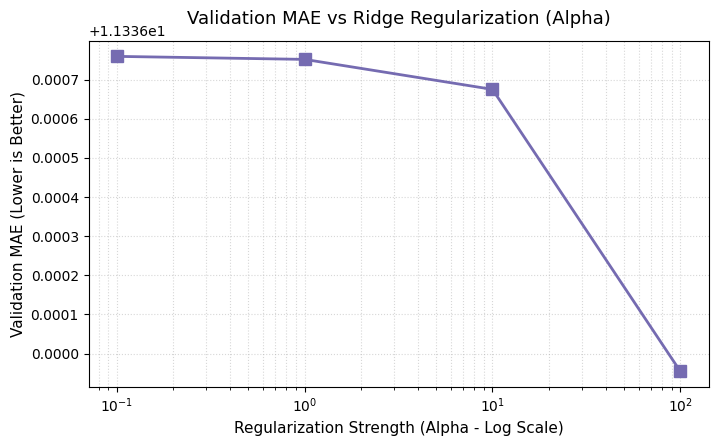

In [2]:
mlflow.set_tracking_uri(config.mlflow.tracking_uri)
experiment = mlflow.get_experiment_by_name(config.mlflow.experiment_name)

# Search all tuning runs under this experiment
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="run_name LIKE 'tune_ridge_alpha_%'",
)

# Parse parameter and metrics
runs["params.alpha"] = runs["params.alpha"].astype(float)
runs = runs.sort_values("params.alpha")

# Plot alpha vs validation MAE
plt.figure(figsize=(8, 4.5))
plt.plot(
    runs["params.alpha"],
    runs["metrics.mae"],
    marker="s",
    color="#756bb1",
    markersize=8,
    linewidth=2,
)
plt.xscale("log")
plt.title(
    "Validation MAE vs Ridge Regularization (Alpha)", fontsize=13, pad=12
)
plt.xlabel("Regularization Strength (Alpha - Log Scale)", fontsize=11)
plt.ylabel("Validation MAE (Lower is Better)", fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()